# Shishaldin event catalog 

gets full window of specified time, filters and denoises it once, runs STA/LTA once on each, and records every trigger with the same metrics as the chunked version 

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from obspy import UTCDateTime, Stream
from obspy.clients.fdsn import Client
from obspy.signal.trigger import recursive_sta_lta, trigger_onset
import seisbench.models as sbm


In [170]:
# params

SOURCE = "IRIS"
NETWORK = "AV"
STATION = "SSLS"
LOCATION = ""
CHANNEL = "BH*"

# interested in last minute, start a minute before for sta/lta START_UP SECONDS
START_TIME = UTCDateTime("2025-10-31T23:58:00")
STOP_TIME = UTCDateTime("2025-11-01T04:00:00")

# padding on each side of the analysis window, trimmed off after
# filtering to remove taper/edge effects
EDGE_TRIM_SECONDS = 5

# params for filtering (bandpass)
FREQMIN = 0.9
FREQMAX = 8.0
CORNERS = 2

# sta/lta parameters
# try to make STARTUP_SECONDS = or > LTA_SECONDS so it has enough time
STA_SECONDS = 1.5
LTA_SECONDS = 30.0
TRIGGER_ON = 2.5
TRIGGER_OFF = 1.0
STARTUP_SECONDS = 120


In [171]:
# load client to get data and model

client = Client(SOURCE)

inv = client.get_stations(
    network=NETWORK,
    station=STATION,
    level="response"
)

model = sbm.DeepDenoiser.from_pretrained("original")


/Users/amelega/miniconda3/envs/deepdenoiser/lib/python3.8/site-packages/seisbench/models/base.py:527: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_weights = torch.loa

In [172]:
# download the whole analysis window in a single request
# (padded on both sides so filtering/tapering doesn't distort the
# edges of the window we actually care about)

download_start = START_TIME - EDGE_TRIM_SECONDS
download_end = STOP_TIME + EDGE_TRIM_SECONDS

stream = client.get_waveforms(
    NETWORK,
    STATION,
    LOCATION,
    CHANNEL,
    download_start,
    download_end
)

# remove instrument response
stream.remove_response(
    inventory=inv,
    output="VEL"
)

raw_trace = stream.select(channel="BHZ")[0].copy()
raw_trace.trim(starttime=START_TIME, endtime=STOP_TIME)

print(raw_trace)


AV.SSLS..BHZ | 2025-10-31T23:58:00.000000Z - 2025-11-01T04:00:00.000000Z | 50.0 Hz, 726001 samples


In [173]:
# filter the full trace once

filtered_full_trace = stream.select(channel="BHZ")[0].copy()

filtered_full_trace.detrend("demean")
filtered_full_trace.detrend("linear")

# filtered_full_trace.taper(max_percentage=0.03)

filtered_full_trace.filter("bandpass", freqmin=FREQMIN, freqmax=FREQMAX, corners=CORNERS, zerophase=True)

# drop the padding now that filtering/tapering is done
filtered_full_trace.trim(starttime=START_TIME, endtime=STOP_TIME)

# want to be 30 minutes
print(filtered_full_trace)


AV.SSLS..BHZ | 2025-10-31T23:58:00.000000Z - 2025-11-01T04:00:00.000000Z | 50.0 Hz, 726001 samples


In [174]:
# run DeepDenoiser once on the full continuous filtered trace

denoised_stream = Stream([filtered_full_trace])
denoised_full = model.annotate(denoised_stream)
denoised_full_trace = denoised_full[0].copy()

# notice upsampling
print(denoised_full_trace)


AV.SSLS..DeepDenoiser_BHZ | 2025-10-31T23:58:00.000000Z - 2025-11-01T04:00:00.010000Z | 100.0 Hz, 1452002 samples


In [175]:
# sta/lta function

def run_sta_lta(trace, sta_seconds=STA_SECONDS, lta_seconds=LTA_SECONDS, trigger_on=TRIGGER_ON, trigger_off=TRIGGER_OFF, startup_seconds=STARTUP_SECONDS):

    fs = trace.stats.sampling_rate
    nsta = int(sta_seconds * fs)
    nlta = int(lta_seconds * fs)

    cft = recursive_sta_lta(trace.data, nsta, nlta)

    # no triggers during startup period because they were bad
    startup_samples = int(startup_seconds * fs)

    cft_for_trigger = cft.copy()
    cft_for_trigger[:startup_samples] = 0
    triggers = trigger_onset(cft_for_trigger, trigger_on, trigger_off)

    return cft, triggers


In [176]:
# run STA/LTA on the continuous filtered and denoised traces

cft_filtered, triggers_filtered = run_sta_lta(filtered_full_trace)
cft_filtered_denoised, triggers_filtered_denoised = run_sta_lta(denoised_full_trace)

n_events_filtered = len(triggers_filtered)
n_events_filtered_denoised = len(triggers_filtered_denoised)

print(f"any NaNs (filtered): {np.isnan(cft_filtered).any()}")
print(f"any NaNs (denoised): {np.isnan(cft_filtered_denoised).any()}")
print(f"number of events in filtered data: {n_events_filtered}")
print(f"number of events in denoised data: {n_events_filtered_denoised}")


any NaNs (filtered): False
any NaNs (denoised): False
number of events in filtered data: 205
number of events in denoised data: 172


In [177]:
# whole-period SNR

def calculate_whole_period_snr(trace, triggers):

    data = trace.data.astype(float)

    signal_mask = np.zeros(len(data), dtype=bool)

    for on, off in triggers:
        signal_mask[on:off] = True

    signal_data = data[signal_mask]
    
    # better ways to calculate noise? 
    noise_data = data[~signal_mask]

    if len(signal_data) == 0 or len(noise_data) == 0:
        return np.nan, np.nan, np.nan

    signal_rms = np.sqrt(np.mean(signal_data ** 2))
    noise_rms = np.sqrt(np.mean(noise_data ** 2))

    if noise_rms == 0:
        snr_db = np.nan
    else:
        snr_db = 20 * np.log10(signal_rms / noise_rms)

    return signal_rms, noise_rms, snr_db


filtered_signal_rms, filtered_noise_rms, filtered_snr_db = (calculate_whole_period_snr(filtered_full_trace, triggers_filtered))

denoised_signal_rms, denoised_noise_rms, denoised_snr_db = (calculate_whole_period_snr(denoised_full_trace, triggers_filtered_denoised))

print("WHOLE-PERIOD SNR")
print("Filtered:")
print(f"  Signal RMS: {filtered_signal_rms:.6e}")
print(f"  Noise RMS:  {filtered_noise_rms:.6e}")
print(f"  SNR:        {filtered_snr_db:.2f} dB")
print()
print("Denoised:")
print(f"  Signal RMS: {denoised_signal_rms:.6e}")
print(f"  Noise RMS:  {denoised_noise_rms:.6e}")
print(f"  SNR:        {denoised_snr_db:.2f} dB")


WHOLE-PERIOD SNR
Filtered:
  Signal RMS: 9.669816e-07
  Noise RMS:  3.568188e-07
  SNR:        8.66 dB

Denoised:
  Signal RMS: 2.540556e-07
  Noise RMS:  3.237572e-08
  SNR:        17.89 dB


In [178]:
# build a long-format event catalog: one row per DETECTION (filtered or denoised).
# events found in both traces share the same event_number; events found in only
# one trace still get their own row/event_number instead of being dropped

def get_window_metrics(trace, window_start, window_end):
    event = trace.copy()
    event.trim(starttime=window_start, endtime=window_end)

    signal_data = event.data.astype(float)
    signal_rms = np.sqrt(np.mean(signal_data ** 2))
    max_amplitude = np.max(np.abs(signal_data))

    noise_duration = LTA_SECONDS
    noise_end = window_start
    noise_start = noise_end - noise_duration

    noise = trace.copy()
    noise.trim(starttime=noise_start, endtime=noise_end)

    if len(noise.data) > 0:
        noise_data = noise.data.astype(float)
        noise_rms = np.sqrt(np.mean(noise_data ** 2))
        snr = (
            20 * np.log10(signal_rms / noise_rms)
            if noise_rms > 0 else np.nan
        )
    else:
        noise_rms, snr = np.nan, np.nan

    return signal_rms, noise_rms, snr, max_amplitude


def triggers_to_intervals(trace, triggers):
    intervals = []
    for on, off in triggers:
        start = trace.stats.starttime + on / trace.stats.sampling_rate
        end = trace.stats.starttime + off / trace.stats.sampling_rate
        intervals.append((start, end))
    return intervals


def intervals_overlap(a_start, a_end, b_start, b_end):
    return a_start < b_end and b_start < a_end


filtered_intervals = triggers_to_intervals(filtered_full_trace, triggers_filtered)
denoised_intervals = triggers_to_intervals(denoised_full_trace, triggers_filtered_denoised)

# assign event numbers: filtered detections are numbered first, in order.
# a denoised detection that overlaps a filtered one gets that SAME event_number.
# any denoised detection left over (no overlap) gets its own new event_number.
event_number = 0
matched_denoised_idx = set()
rows = []

for f_start, f_end in filtered_intervals:
    event_number += 1

    signal_rms, noise_rms, snr_db, max_amplitude = get_window_metrics(
        filtered_full_trace, f_start, f_end
    )

    rows.append({
        "event_number": event_number,
        "detection_type": "filtered",
        "start_time": f_start.strftime("%Y-%m-%dT%H:%M:%S.%f"),
        "end_time": f_end.strftime("%Y-%m-%dT%H:%M:%S.%f"),
        "duration_seconds": float(f_end - f_start),
        "signal_rms": float(signal_rms),
        "noise_rms": float(noise_rms),
        "snr_db": float(snr_db),
        "max_amplitude": float(max_amplitude),
    })

    # look for a denoised detection overlapping this filtered one (first match)
    for d_idx, (d_start, d_end) in enumerate(denoised_intervals):
        if d_idx in matched_denoised_idx:
            continue
        if intervals_overlap(f_start, f_end, d_start, d_end):
            matched_denoised_idx.add(d_idx)

            d_signal_rms, d_noise_rms, d_snr_db, d_max_amplitude = get_window_metrics(
                denoised_full_trace, d_start, d_end
            )

            rows.append({
                "event_number": event_number,
                "detection_type": "denoised",
                "start_time": d_start.strftime("%Y-%m-%dT%H:%M:%S.%f"),
                "end_time": d_end.strftime("%Y-%m-%dT%H:%M:%S.%f"),
                "duration_seconds": float(d_end - d_start),
                "signal_rms": float(d_signal_rms),
                "noise_rms": float(d_noise_rms),
                "snr_db": float(d_snr_db),
                "max_amplitude": float(d_max_amplitude),
            })
            break

# any denoised detections that never matched a filtered one get new event numbers
for d_idx, (d_start, d_end) in enumerate(denoised_intervals):
    if d_idx in matched_denoised_idx:
        continue

    event_number += 1

    signal_rms, noise_rms, snr_db, max_amplitude = get_window_metrics(
        denoised_full_trace, d_start, d_end
    )

    rows.append({
        "event_number": event_number,
        "detection_type": "denoised",
        "start_time": d_start.strftime("%Y-%m-%dT%H:%M:%S.%f"),
        "end_time": d_end.strftime("%Y-%m-%dT%H:%M:%S.%f"),
        "duration_seconds": float(d_end - d_start),
        "signal_rms": float(signal_rms),
        "noise_rms": float(noise_rms),
        "snr_db": float(snr_db),
        "max_amplitude": float(max_amplitude),
    })

event_results = pd.DataFrame(rows).sort_values(["event_number", "detection_type"]).reset_index(drop=True)

def format_float(x):
    if pd.isna(x):
        return ""

    x = float(x)

    if x == 0:
        return "0.00"

    exponent = int(np.floor(np.log10(abs(x))))

    if exponent >= 3 or exponent <= -3:
        return f"{x:.2e}"
    else:
        return f"{x:.2f}"

event_results_csv = event_results.copy()
numeric_columns = event_results_csv.select_dtypes(include="number").columns

for col in numeric_columns:
    event_results_csv[col] = event_results_csv[col].map(format_float)

# save csv
event_results_csv.to_csv("shishaldin_event_metrics.csv", index=False)

n_matched = len(matched_denoised_idx)
n_filtered_only = len(filtered_intervals) - n_matched
n_denoised_only = len(denoised_intervals) - n_matched

print(f"filtered detections: {len(filtered_intervals)}")
print(f"denoised detections: {len(denoised_intervals)}")
print(f"matched (same event_number in both): {n_matched}")
print(f"filtered-only events: {n_filtered_only}")
print(f"denoised-only events: {n_denoised_only}")
print(f"total rows saved: {len(event_results)}")

event_results.head(10)


filtered detections: 205
denoised detections: 172
matched (same event_number in both): 151
filtered-only events: 54
denoised-only events: 21
total rows saved: 377


,event_number,detection_type,start_time,end_time,duration_seconds,signal_rms,noise_rms,snr_db,max_amplitude
0,1,filtered,2025-11-01T00:00:45.160000,2025-11-01T00:00:53.520000,8.36,2.189985e-07,1.916326e-07,1.159433,6.564448e-07
1,2,filtered,2025-11-01T00:01:18.080000,2025-11-01T00:01:27.680000,9.60,5.286678e-07,2.589101e-07,6.200678,1.357615e-06
2,3,filtered,2025-11-01T00:01:28.900000,2025-11-01T00:01:34.820000,5.92,4.282577e-07,3.853008e-07,0.918107,1.428075e-06
3,4,denoised,2025-11-01T00:02:15.250000,2025-11-01T00:02:50.910000,35.66,3.425247e-07,6.266247e-09,34.753688,2.185923e-06
4,4,filtered,2025-11-01T00:02:15.740000,2025-11-01T00:02:25.000000,9.26,6.300304e-07,3.312399e-07,5.584377,1.682944e-06
5,5,filtered,2025-11-01T00:02:41.780000,2025-11-01T00:02:52.360000,10.58,1.679284e-06,4.901078e-07,10.696648,6.126825e-06
6,6,denoised,2025-11-01T00:04:21.360000,2025-11-01T00:04:31.820000,10.46,3.155693e-07,4.143403e-08,17.634753,1.031801e-06
7,6,filtered,2025-11-01T00:04:19.760000,2025-11-01T00:04:29.160000,9.40,1.115754e-06,3.502089e-07,10.064823,3.378798e-06
8,7,denoised,2025-11-01T00:05:12.910000,2025-11-01T00:05:27.500000,14.59,3.984021e-07,6.529012e-08,15.709484,1.306408e-06
9,7,filtered,2025-11-01T00:05:13.800000,2025-11-01T00:05:24.920000,11.12,1.812658e-06,5.184488e-07,10.872200,5.071582e-06


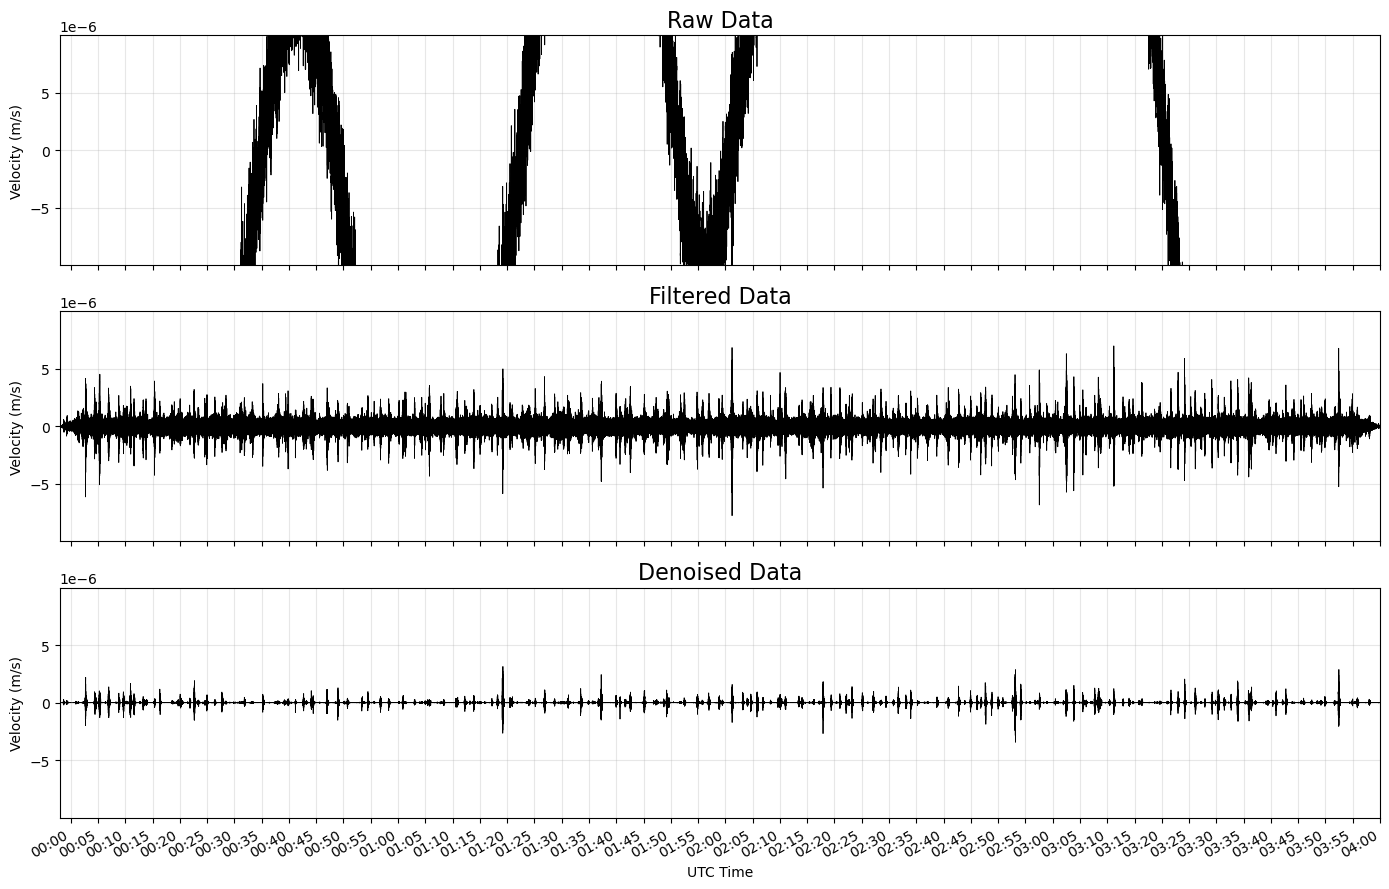

In [179]:
# plot raw / filtered / denoised waveforms

times_raw = raw_trace.times("matplotlib")
times_filtered = filtered_full_trace.times("matplotlib")
times_denoised = denoised_full_trace.times("matplotlib")

waveform_ylim = (-10e-6, 10e-6)
waveform_yticks = [-5e-6, 0, 5e-6]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(times_raw, raw_trace.data, linewidth=0.6, color="black")
axes[0].set_title("Raw Data", fontsize=16)
axes[0].set_ylabel("Velocity (m/s)")
axes[0].set_ylim(waveform_ylim)
axes[0].set_yticks(waveform_yticks)
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_filtered, filtered_full_trace.data, linewidth=0.6, color="black")
axes[1].set_title("Filtered Data", fontsize=16)
axes[1].set_ylabel("Velocity (m/s)")
axes[1].set_ylim(waveform_ylim)
axes[1].set_yticks(waveform_yticks)
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[1].grid(True, alpha=0.3)

axes[2].plot(times_denoised, denoised_full_trace.data, linewidth=0.6, color="black")
axes[2].set_title("Denoised Data", fontsize=16)
axes[2].set_ylabel("Velocity (m/s)")
axes[2].set_xlabel("UTC Time")
axes[2].set_ylim(waveform_ylim)
axes[2].set_yticks(waveform_yticks)
axes[2].ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


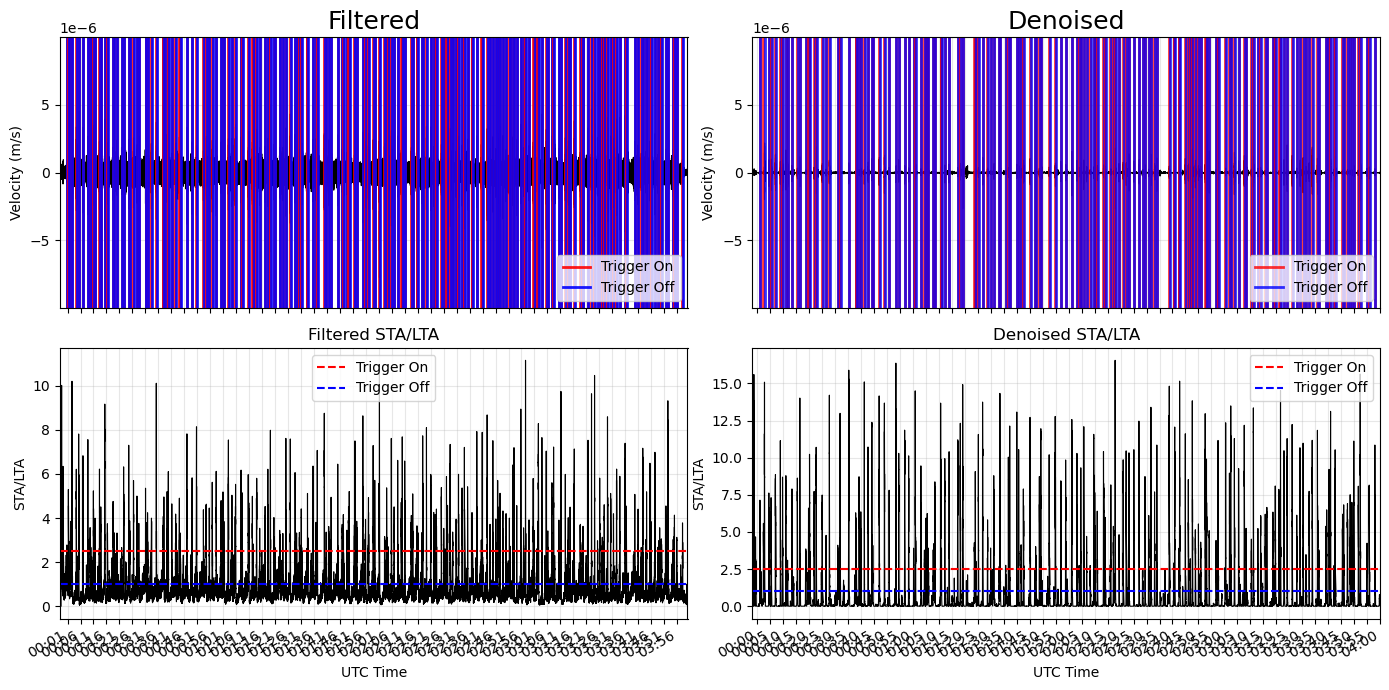

In [180]:
# plot filtered vs denoised waveforms with STA/LTA triggers

times_filtered = filtered_full_trace.times("matplotlib")
times_filtered_denoised = denoised_full_trace.times("matplotlib")

waveform_ylim = (-10e-6, 10e-6)
waveform_yticks = [-5e-6, 0, 5e-6]

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex="col")

ax = axes[0, 0]
ax.plot(times_filtered, filtered_full_trace.data, linewidth=0.8, color="black")
ax.set_title("Filtered", fontsize=18)
ax.set_ylabel("Velocity (m/s)")
ax.set_yticks(waveform_yticks)
ax.set_ylim(waveform_ylim)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))

for i, (on, off) in enumerate(triggers_filtered):
    ax.axvline(times_filtered[on], color="red", linewidth=2, alpha=0.9,
               label="Trigger On" if i == 0 else None)
    ax.axvline(times_filtered[off], color="blue", linewidth=2, alpha=0.9,
               label="Trigger Off" if i == 0 else None)

ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(times_filtered_denoised, denoised_full_trace.data, linewidth=0.8, color="black")
ax.set_title("Denoised", fontsize=18)
ax.set_ylabel("Velocity (m/s)")
ax.set_yticks(waveform_yticks)
ax.set_ylim(waveform_ylim)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, 6))

for i, (on, off) in enumerate(triggers_filtered_denoised):
    ax.axvline(times_filtered_denoised[on], color="red", linewidth=2, alpha=0.8,
               label="Trigger On" if i == 0 else None)
    ax.axvline(times_filtered_denoised[off], color="blue", linewidth=2, alpha=0.8,
               label="Trigger Off" if i == 0 else None)

ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(times_filtered, cft_filtered, linewidth=0.8, color="black")
ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
ax.set_ylabel("STA/LTA")
ax.set_xlabel("UTC Time")
ax.set_title("Filtered STA/LTA")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(times_filtered_denoised, cft_filtered_denoised, linewidth=0.8, color="black")
ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
ax.set_ylabel("STA/LTA")
ax.set_xlabel("UTC Time")
ax.set_title("Denoised STA/LTA")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


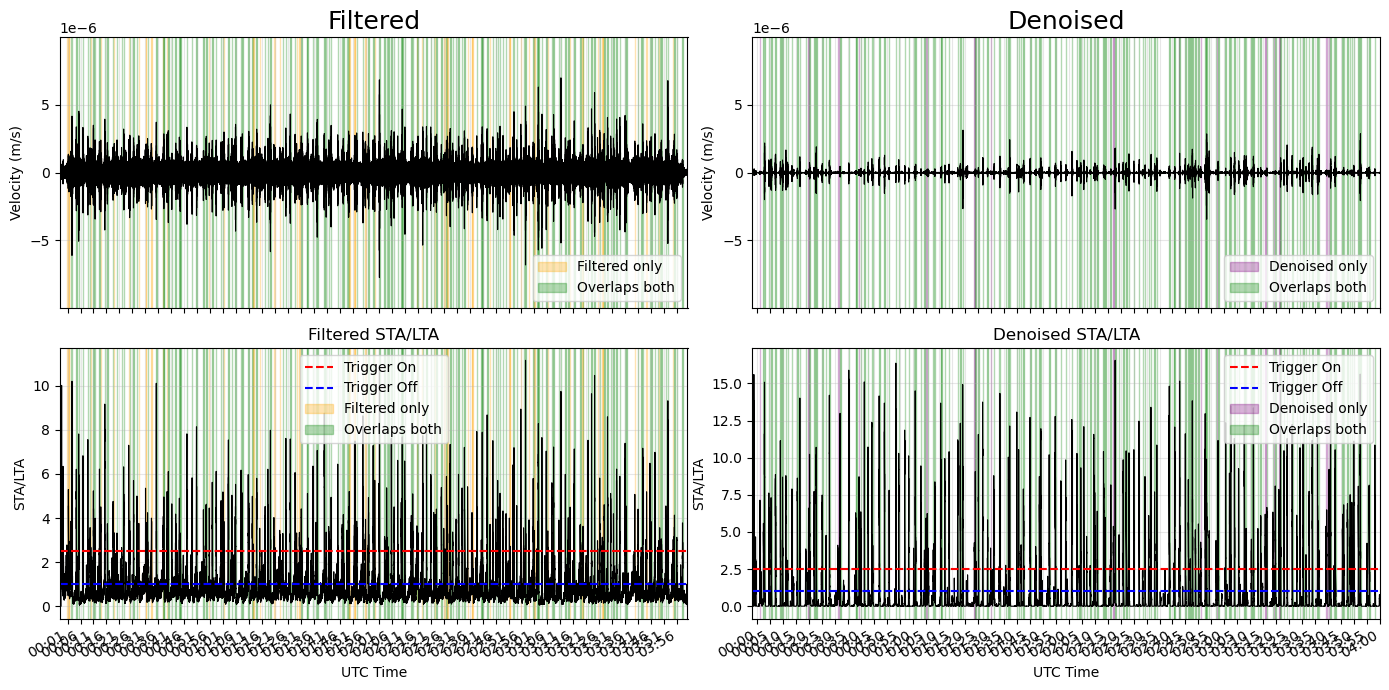

In [181]:
# plot filtered vs denoised waveforms with STA/LTA triggers,
# shaded by whether the event overlaps between filtered and denoised detections

def to_mpl(t):
    return t.matplotlib_date

def intervals_overlap(a_start, a_end, b_start, b_end):
    return a_start < b_end and b_start < a_end

# convert triggers to UTCDateTime intervals
filtered_intervals = [
    (filtered_full_trace.stats.starttime + on / filtered_full_trace.stats.sampling_rate,
     filtered_full_trace.stats.starttime + off / filtered_full_trace.stats.sampling_rate,)
    for on, off in triggers_filtered]

denoised_intervals = [
    (denoised_full_trace.stats.starttime + on / denoised_full_trace.stats.sampling_rate,
     denoised_full_trace.stats.starttime + off / denoised_full_trace.stats.sampling_rate,)
    for on, off in triggers_filtered_denoised]

# flag whether each event has a match in the other trace's detections
filtered_overlap_flags = [any(intervals_overlap(fs, fe, ds, de) for ds, de in denoised_intervals)
    for fs, fe in filtered_intervals]

denoised_overlap_flags = [any(intervals_overlap(ds, de, fs, fe) for fs, fe in filtered_intervals)
    for ds, de in denoised_intervals]

OVERLAP_COLOR = "green"
FILTERED_ONLY_COLOR = "orange"
DENOISED_ONLY_COLOR = "purple"

def shade_events(ax, intervals, overlap_flags, only_label):
    seen_overlap = False
    seen_only = False
    for (start, end), overlaps in zip(intervals, overlap_flags):
        color = OVERLAP_COLOR if overlaps else (
            FILTERED_ONLY_COLOR if only_label == "Filtered only" else DENOISED_ONLY_COLOR
        )
        label = None
        if overlaps and not seen_overlap:
            label = "Overlaps both"
            seen_overlap = True
        elif not overlaps and not seen_only:
            label = only_label
            seen_only = True
        ax.axvspan(to_mpl(start), to_mpl(end), color=color, alpha=0.3, label=label)


times_filtered = filtered_full_trace.times("matplotlib")
times_filtered_denoised = denoised_full_trace.times("matplotlib")

waveform_ylim = (-10e-6, 10e-6)
waveform_yticks = [-5e-6, 0, 5e-6]

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex="col")

ax = axes[0, 0]
ax.plot(times_filtered, filtered_full_trace.data, linewidth=0.8, color="black")
ax.set_title("Filtered", fontsize=18)
ax.set_ylabel("Velocity (m/s)")
ax.set_yticks(waveform_yticks)
ax.set_ylim(waveform_ylim)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, -6))
shade_events(ax, filtered_intervals, filtered_overlap_flags, "Filtered only")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(times_filtered_denoised, denoised_full_trace.data, linewidth=0.8, color="black")
ax.set_title("Denoised", fontsize=18)
ax.set_ylabel("Velocity (m/s)")
ax.set_yticks(waveform_yticks)
ax.set_ylim(waveform_ylim)
ax.ticklabel_format(axis="y", style="sci", scilimits=(-6, 6))
shade_events(ax, denoised_intervals, denoised_overlap_flags, "Denoised only")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(times_filtered, cft_filtered, linewidth=0.8, color="black")
ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
shade_events(ax, filtered_intervals, filtered_overlap_flags, "Filtered only")
ax.set_ylabel("STA/LTA")
ax.set_xlabel("UTC Time")
ax.set_title("Filtered STA/LTA")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(times_filtered_denoised, cft_filtered_denoised, linewidth=0.8, color="black")
ax.axhline(TRIGGER_ON, color="red", linestyle="--", linewidth=1.5, label="Trigger On")
ax.axhline(TRIGGER_OFF, color="blue", linestyle="--", linewidth=1.5, label="Trigger Off")
shade_events(ax, denoised_intervals, denoised_overlap_flags, "Denoised only")
ax.set_ylabel("STA/LTA")
ax.set_xlabel("UTC Time")
ax.set_title("Denoised STA/LTA")
ax.legend()
ax.grid(True, alpha=0.3)

for ax in axes.flat:
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [182]:
# Calculate detection durations in seconds
filtered_durations = [
    end - start
    for start, end in filtered_intervals
]

denoised_durations = [
    end - start
    for start, end in denoised_intervals
]

print("Filtered durations:")
for i, duration in enumerate(filtered_durations):
    print(f"Event {i+1}: {duration:.2f} s")

print("\nDenoised durations:")
for i, duration in enumerate(denoised_durations):
    print(f"Event {i+1}: {duration:.2f} s")


Filtered durations:
Event 1: 8.36 s
Event 2: 9.60 s
Event 3: 5.92 s
Event 4: 9.26 s
Event 5: 10.58 s
Event 6: 9.40 s
Event 7: 11.12 s
Event 8: 11.64 s
Event 9: 10.30 s
Event 10: 9.92 s
Event 11: 4.50 s
Event 12: 11.00 s
Event 13: 8.18 s
Event 14: 10.20 s
Event 15: 7.32 s
Event 16: 15.64 s
Event 17: 7.28 s
Event 18: 10.12 s
Event 19: 4.48 s
Event 20: 10.10 s
Event 21: 7.40 s
Event 22: 11.84 s
Event 23: 10.18 s
Event 24: 10.32 s
Event 25: 7.98 s
Event 26: 10.40 s
Event 27: 8.12 s
Event 28: 10.42 s
Event 29: 7.94 s
Event 30: 8.66 s
Event 31: 7.20 s
Event 32: 9.62 s
Event 33: 5.60 s
Event 34: 11.94 s
Event 35: 8.74 s
Event 36: 8.92 s
Event 37: 7.40 s
Event 38: 8.44 s
Event 39: 13.44 s
Event 40: 8.84 s
Event 41: 11.82 s
Event 42: 14.32 s
Event 43: 11.54 s
Event 44: 9.06 s
Event 45: 10.52 s
Event 46: 9.78 s
Event 47: 5.58 s
Event 48: 11.58 s
Event 49: 9.58 s
Event 50: 10.04 s
Event 51: 14.64 s
Event 52: 13.98 s
Event 53: 7.92 s
Event 54: 9.08 s
Event 55: 16.78 s
Event 56: 19.12 s
Event 57: 7

In [183]:
# print overlap counts

n_filtered_overlap = sum(filtered_overlap_flags)
n_filtered_only = len(filtered_overlap_flags) - n_filtered_overlap

n_denoised_overlap = sum(denoised_overlap_flags)
n_denoised_only = len(denoised_overlap_flags) - n_denoised_overlap

print("EVENT OVERLAP SUMMARY")
print(f"filtered events total:     {len(filtered_intervals)}")
print(f"  overlapping w/ denoised: {n_filtered_overlap}")
print(f"  filtered only:           {n_filtered_only}")
print()
print(f"denoised events total:     {len(denoised_intervals)}")
print(f"  overlapping w/ filtered: {n_denoised_overlap}")
print(f"  denoised only:           {n_denoised_only}")

EVENT OVERLAP SUMMARY
filtered events total:     205
  overlapping w/ denoised: 152
  filtered only:           53

denoised events total:     172
  overlapping w/ filtered: 153
  denoised only:           19


count    377.000000
mean      10.680955
std        3.662010
min        1.840000
25%        8.440000
50%       10.380000
75%       12.280000
max       35.660000
Name: duration_seconds, dtype: float64


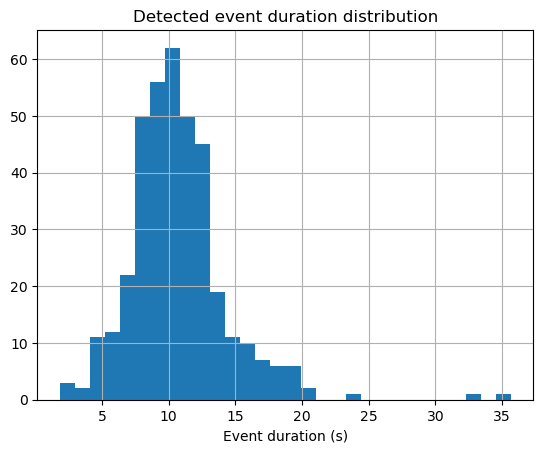

In [184]:
# inspect event durations
print(event_results["duration_seconds"].describe())
event_results["duration_seconds"].hist(bins=30)
plt.xlabel("Event duration (s)")
plt.title("Detected event duration distribution")
plt.show()

In [73]:
# inspect the filtered-only events: how close did the denoised trace
# come to triggering during that same time window?

print("FILTERED-ONLY EVENTS")

for (start, end), overlaps in zip(filtered_intervals, filtered_overlap_flags):
    if overlaps:
        continue

    on_idx = int((start - denoised_full_trace.stats.starttime) * denoised_full_trace.stats.sampling_rate)
    off_idx = int((end - denoised_full_trace.stats.starttime) * denoised_full_trace.stats.sampling_rate)
    on_idx = max(on_idx, 0)
    off_idx = min(off_idx, len(cft_filtered_denoised))

    window_cft = cft_filtered_denoised[on_idx:off_idx]
    peak_cft = np.nanmax(window_cft) if len(window_cft) else np.nan

    print(
        f"{start} - {end}  "
        f"(duration {end - start:.2f}s)  "
        f"peak denoised STA/LTA in window: {peak_cft:.2f}  "
        f"(trigger threshold: {TRIGGER_ON})"
    )

FILTERED-ONLY EVENTS
2025-11-01T00:04:39.560000Z - 2025-11-01T00:04:44.360000Z  (duration 4.80s)  peak denoised STA/LTA in window: 1.37  (trigger threshold: 2.0)
2025-11-01T00:09:58.340000Z - 2025-11-01T00:10:03.200000Z  (duration 4.86s)  peak denoised STA/LTA in window: 0.08  (trigger threshold: 2.0)
2025-11-01T00:10:17.180000Z - 2025-11-01T00:10:23.180000Z  (duration 6.00s)  peak denoised STA/LTA in window: 0.11  (trigger threshold: 2.0)
2025-11-01T00:13:48.360000Z - 2025-11-01T00:13:55.720000Z  (duration 7.36s)  peak denoised STA/LTA in window: 1.98  (trigger threshold: 2.0)
2025-11-01T00:18:06.860000Z - 2025-11-01T00:18:10.300000Z  (duration 3.44s)  peak denoised STA/LTA in window: 0.01  (trigger threshold: 2.0)
2025-11-01T00:18:59.580000Z - 2025-11-01T00:19:04.100000Z  (duration 4.52s)  peak denoised STA/LTA in window: 0.37  (trigger threshold: 2.0)
2025-11-01T00:21:25.260000Z - 2025-11-01T00:21:32.780000Z  (duration 7.52s)  peak denoised STA/LTA in window: 0.46  (trigger threshol